# Регуляризація та функції активації в нейронних мережах


## Бізнес-контекст
Компанія HealthRisk Analytics продовжує покращувати модель прогнозування медичних ризиків.
Команда розробників хоче зрозуміти, як різні функції активації та прийоми регуляризації (Dropout, Batch Normalization) впливають на стабільність і якість навчання моделі. Ваше завдання — провести серію експериментів і порівняти результати.

## Завдання 1
Дослідіть вплив функцій активації на результати моделі.
- Згенеруйте синтетичні дані для регресії за допомогою функції make_regression (2000 рядків, 10 ознак, noise=10, random_state=42).
- Побудуйте модель MLP з одним прихованим прошарком із 32 нейронів.
- Послідовно застосуйте різні функції активації: ReLU, Tanh, LeakyReLU, Swish.
- Для кожної активації розрахуйте MAE і R² на тестовій вибірці.
- Оформіть результати в таблиці:

|Активація|MAE|R²|
|-|-|-|
|ReLU|...|...|
|Tanh|...|...|
|LeakyReLU|...|...|
|Swish|...|...|

In [1]:
# Згенеруйте синтетичні дані для регресії за допомогою функції make_regression (2000 рядків, 10 ознак, noise=10, random_state=42)
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=2000, n_features=10, noise=10, random_state=42)
X[0]

array([-1.38301781, -0.18140603,  0.73752806,  0.27524869,  0.51141526,
        1.50808285,  0.60673   ,  0.94782078, -2.09317802, -1.07681697])

In [2]:
# для оцінювання якості навчання розділяємо дані на навчальні та тестові
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"train: {len(xtrain)}, test: {len(xtest)}")

train: 1600, test: 400


In [3]:
# готуємо функції активації ReLU, Tanh, LeakyReLU, Swish.
import torch.nn as nn
activators = {
    "Sigmoid": nn.Sigmoid(),
    "ReLU": nn.ReLU(),
    "Tanh": nn.Tanh(),
    "LeakyReLU": nn.LeakyReLU(),
    "Swish": nn.SiLU(),
}

In [4]:
# Побудуйте модель MLP з одним прихованим прошарком із 32 нейронів.
class Mlp(nn.Module):
    def __init__(self, input_size=10, hidden_size=32, output_size=1, activator="Sigmoid"):
        super(Mlp,self).__init__()
        self.activation = activators.get(activator, None)
        if self.activation is None:
            raise ValueError("Undefined activator " + activator)
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            self.activation,
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.layers(x)

In [5]:
# для навчання нейромережі дані мають бути тензорами
import torch
xtrain = torch.tensor(xtrain, dtype=torch.float32)
xtest  = torch.tensor(xtest,  dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.float32).reshape(-1,1)
ytest  = torch.tensor(ytest,  dtype=torch.float32).reshape(-1,1)

In [6]:
# для роботи з множиною об'єктів-моделей створимо функцію навчання моделі
def train_model(model, X, y, epochs=1000, lr=0.01):
    loss_f = nn.functional.mse_loss
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        output = model(X)
        loss = loss_f(output, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

In [7]:
# створюємо перелік моделей з різними фукціями активації
models = [Mlp(activator=k) for k in activators.keys()]
models

[Mlp(
   (activation): Sigmoid()
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): Sigmoid()
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 Mlp(
   (activation): ReLU()
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): ReLU()
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 Mlp(
   (activation): Tanh()
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): Tanh()
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 Mlp(
   (activation): LeakyReLU(negative_slope=0.01)
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): LeakyReLU(negative_slope=0.01)
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 Mlp(
   (activation): SiLU()
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): SiLU()
     

In [8]:
losses = [train_model(m, xtrain, ytrain) for m in models]
print(*zip(*(ls[:15] for ls in losses)), sep='\n')

(40293.4140625, 40314.3046875, 40356.53125, 40265.16796875, 40296.15625)
(40209.9609375, 39990.19921875, 39654.71484375, 39144.12890625, 39723.75)
(39995.30078125, 36023.9765625, 33935.078125, 26670.931640625, 33609.515625)
(39349.015625, 7688.97802734375, 20740.578125, 27447.935546875, 2383.926513671875)
(37822.984375, 91890.34375, 12474.142578125, 9486.5830078125, 36036.0390625)
(35138.9140625, 2444762.0, 9256.3818359375, 40340.9140625, 59278.21875)
(31555.5234375, 85427380224.0, 7655.2568359375, 31485.9453125, 40323.32421875)
(27609.95703125, 8.215908873876652e+24, 7057.52490234375, 30202.25, 35932.61328125)
(23802.279296875, inf, 18249.240234375, 36338.08203125, 22853.544921875)
(20450.54296875, nan, 16129.3447265625, 20060.361328125, 56645.78515625)
(17656.162109375, nan, 6750.01123046875, 30107.4296875, 195515.1875)
(15398.0478515625, nan, 5758.67822265625, 42866.3515625, 2797271.0)
(13603.357421875, nan, 5148.349609375, 30492.3828125, 164784603136.0)
(12186.2763671875, nan, 4643

In [28]:
import matplotlib.pyplot as plt
labels = list(activators.keys())

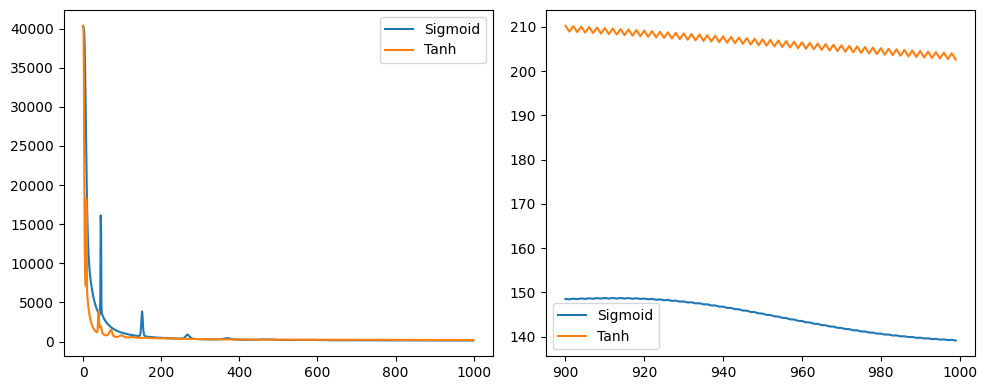

In [31]:
_,(ax, ax2) = plt.subplots(1,2, figsize=(10,4))
for i in (0, 2):
    ax.plot(range(1000), losses[i], label=labels[i])
ax.legend()
for i in (0, 2):
    ax2.plot(range(900,1000), losses[i][900:], label=labels[i])
ax2.legend()
plt.tight_layout()
plt.show()

Ефект "вибуху градієнту" виникає при великих величинах входу і призводить до того, що модель не навчається. Напрямки дій - а) зменшити learning rate, б) масштабувати дані (вхідні)

In [18]:
# Використаємо масштабування (нормалізацію) даних
X2, y2 = make_regression(n_samples=2000, n_features=10, noise=10, random_state=42)
xtrain2, xtest2, ytrain2, ytest2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler()
xtrain2 = scaler_x.fit_transform(xtrain2)  # навчаємо scaler на навчальній вибірці
xtest2 = scaler_x.transform(xtest2)        # для тестової - вживаємо навчений scaler
scaler_y = StandardScaler()
ytrain2 = scaler_y.fit_transform(ytrain2.reshape(-1,1))  # навчаємо scaler на навчальній вибірці
ytest2 = scaler_y.transform(ytest2.reshape(-1,1))        # для тестової - вживаємо навчений scaler

xtrain2 = torch.tensor(xtrain2, dtype=torch.float32)
xtest2  = torch.tensor(xtest2,  dtype=torch.float32)
ytrain2 = torch.tensor(ytrain2, dtype=torch.float32) 
ytest2  = torch.tensor(ytest2,  dtype=torch.float32) 

models2 = [Mlp(activator=k) for k in activators.keys()]
losses2 = [train_model(m, xtrain2, ytrain2) for m in models2]
print(*zip(*(ls[:15] for ls in losses2)), sep='\n')

(1.041640043258667, 0.7941081523895264, 0.9370374083518982, 1.0957976579666138, 0.882454514503479)
(1.0267972946166992, 0.7771216630935669, 0.9030159711837769, 1.0752980709075928, 0.8676959276199341)
(1.015673041343689, 0.7609686851501465, 0.8704900145530701, 1.0557876825332642, 0.8532505631446838)
(1.0070302486419678, 0.7455457448959351, 0.8393635749816895, 1.0371668338775635, 0.8391001224517822)
(1.0000447034835815, 0.7307685613632202, 0.8095487356185913, 1.019344449043274, 0.8252274990081787)
(0.9941678047180176, 0.716570258140564, 0.7809654474258423, 1.0022488832473755, 0.8116169571876526)
(0.9890338182449341, 0.7028824090957642, 0.7535400390625, 0.9858095049858093, 0.7982543706893921)
(0.9843990802764893, 0.6896457076072693, 0.7272055149078369, 0.9699560403823853, 0.7851265668869019)
(0.9801016449928284, 0.6768134236335754, 0.7018997073173523, 0.954633355140686, 0.7722212076187134)
(0.976033091545105, 0.6643525958061218, 0.6775659322738647, 0.9398040771484375, 0.7595272660255432)


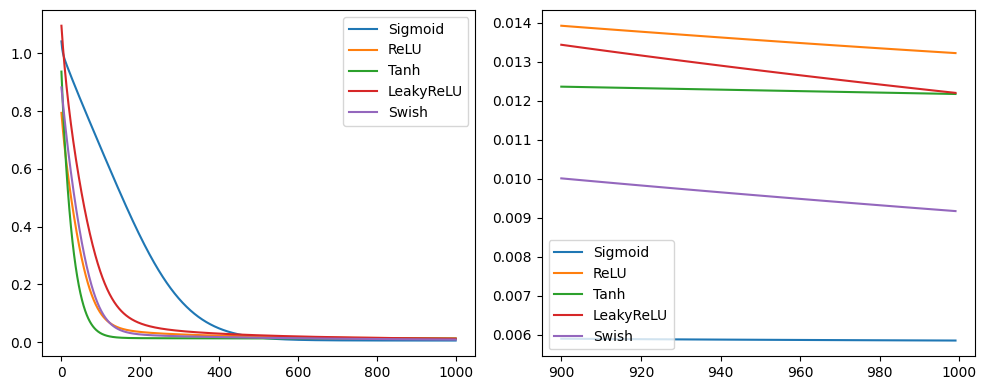

In [23]:

_,(ax, ax2) = plt.subplots(1,2, figsize=(10,4))
for i in range(len(activators)):
    ax.plot(range(1000), losses2[i], label=labels[i])
ax.legend()
for i in range(len(activators)):
    ax2.plot(range(900,1000), losses2[i][900:], label=labels[i])
ax2.legend()
plt.tight_layout()
plt.show()

In [27]:
# Для кожної активації розрахуйте MAE і R² на тестовій вибірці.
import sklearn.metrics as sm
predictions = [m(xtest2) for m in models2]
with torch.no_grad():
    mae_scores = [sm.mean_absolute_error(ytest2, p) for p in predictions]
    r2_scores = [sm.r2_score(ytest2, p) for p in predictions]

from IPython.display import Markdown as md
md("\n".join((
    "|Активація|MAE|R²|",
    "|-|-|-|",
    *(f"|{labels[i]}|{mae_scores[i]}|{r2_scores[i]}|" for i in range(len(activators)))
)))

|Активація|MAE|R²|
|-|-|-|
|Sigmoid|0.051438797265291214|0.9953095316886902|
|ReLU|0.08853492885828018|0.9863454699516296|
|Tanh|0.07991614192724228|0.9874321222305298|
|LeakyReLU|0.0907704159617424|0.9857664108276367|
|Swish|0.07305219024419785|0.9898409843444824|

4
